<a href="https://colab.research.google.com/github/pandey06/Deep-Learning-/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RNN vs LSTM vs GRU for Sequence Classification
Assignment: Implement and compare RNN, LSTM, and GRU models for sequence classification and analyze their performance using appropriate evaluation metrics.

Dataset: IMDB Movie Review Sentiment Dataset
Task: Binary sentiment classification
Classes: 0 = Negative, 1 = Positive

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [23]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))
print("First review length:", len(X_train_raw[0]))
print("First label:", y_train[0])


Training samples: 25000
Testing samples: 25000
First review length: 218
First label: 1


Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364

Class distribution:
0    12500
1    12500
Name: count, dtype: int64


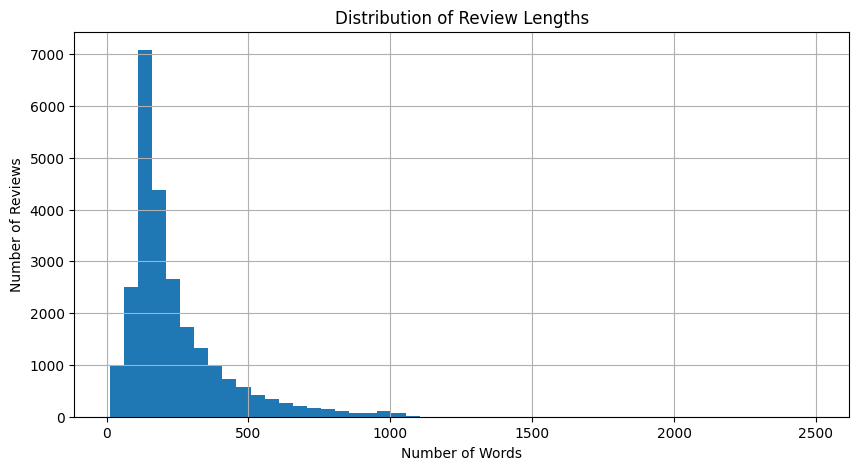

In [24]:
train_lengths = [len(x) for x in X_train_raw]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))
print("Average review length:", np.mean(train_lengths))

print("\nClass distribution:")
print(pd.Series(y_train).value_counts().sort_index())

plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [25]:
X_train = pad_sequences(
    X_train_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_raw,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


In [44]:
def build_rnn_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [27]:
rnn_model = build_rnn_model()
print('RNN model created.')

RNN model created.


In [28]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.5030 - loss: 0.6954 - val_accuracy: 0.4970 - val_loss: 0.6939
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.5545 - loss: 0.6832 - val_accuracy: 0.4936 - val_loss: 0.6973
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.6274 - loss: 0.6174 - val_accuracy: 0.5048 - val_loss: 0.7750


In [45]:
def build_lstm_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64),
        LSTM(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [30]:
lstm_model = build_lstm_model()
print('LSTM model created.')

LSTM model created.


In [31]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 320ms/step - accuracy: 0.5229 - loss: 0.6906 - val_accuracy: 0.4952 - val_loss: 0.6946
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 315ms/step - accuracy: 0.5238 - loss: 0.6921 - val_accuracy: 0.5268 - val_loss: 0.6934
Epoch 3/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 303ms/step - accuracy: 0.5630 - loss: 0.6786 - val_accuracy: 0.5720 - val_loss: 0.6575
Epoch 4/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 317ms/step - accuracy: 0.6180 - loss: 0.6547 - val_accuracy: 0.5290 - val_loss: 0.6818
Epoch 5/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 317ms/step - accuracy: 0.6069 - loss: 0.6306 - val_accuracy: 0.6356 - val_loss: 0.6218
Epoch 6/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 306ms/step - accuracy: 0.7402 - loss: 0.5185 - val_accuracy: 0.7728 - val_loss: 0.5286
Epoch 7/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 309ms/step - accuracy: 0.8111 - loss: 0.4640 - val_accuracy: 0.7414 - val_loss: 0.5618
Epoch 8/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 316ms/step - accuracy: 0.8480 - loss: 0.3987 - 

In [46]:
def build_gru_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 64),
        GRU(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [33]:
gru_model = build_gru_model()
print('GRU model created.')

GRU model created.


In [34]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 368ms/step - accuracy: 0.5046 - loss: 0.6930 - val_accuracy: 0.5182 - val_loss: 0.6918
Epoch 2/8
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 357ms/step - accuracy: 0.5745 - loss: 0.6665 - val_accuracy: 0.6122 - val_loss: 0.6365


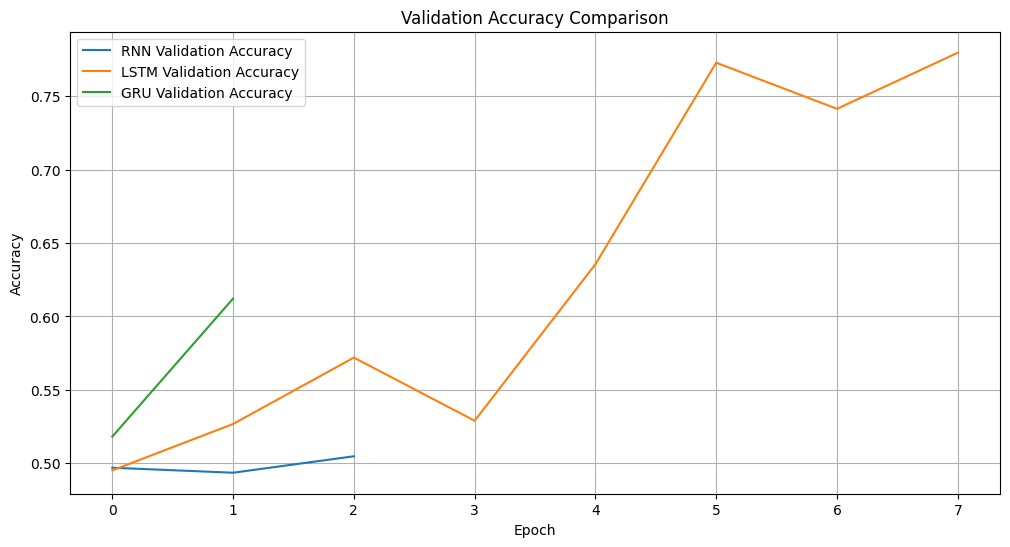

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(rnn_history.history["val_accuracy"], label="RNN Validation Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM Validation Accuracy")
plt.plot(gru_history.history["val_accuracy"], label="GRU Validation Accuracy")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

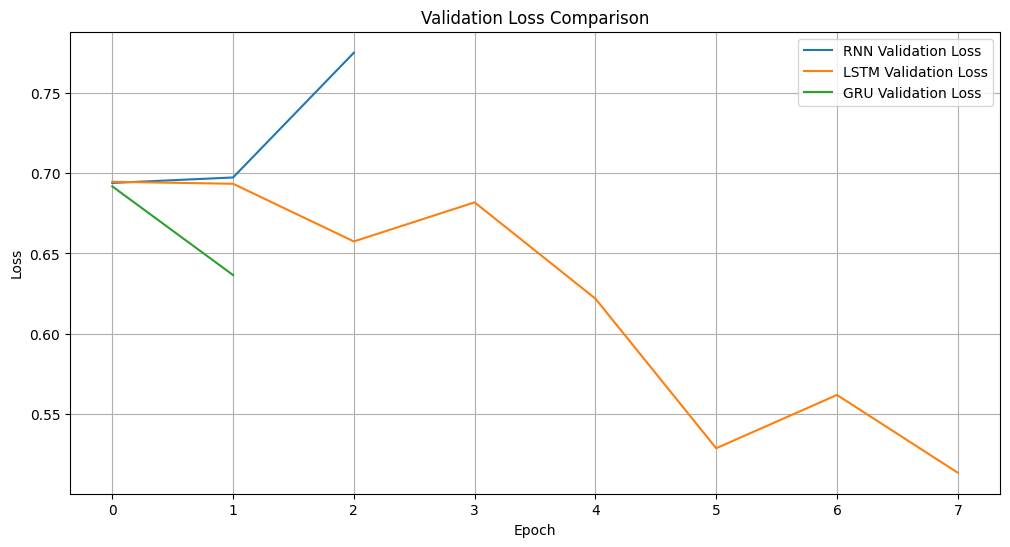

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(rnn_history.history["val_loss"], label="RNN Validation Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation Loss")
plt.plot(gru_history.history["val_loss"], label="GRU Validation Loss")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [37]:
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = []

predictions_dict = {}

for name, model in models.items():
    probabilities = model.predict(X_test, batch_size=128, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    predictions_dict[name] = predictions

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

display(results_df.round(4))

,Accuracy,Precision,Recall,F1 Score
Model,,,,
RNN,0.4984,0.4970,0.2611,0.3424
LSTM,0.7724,0.8003,0.7260,0.7614
GRU,0.5120,0.5190,0.3281,0.4020


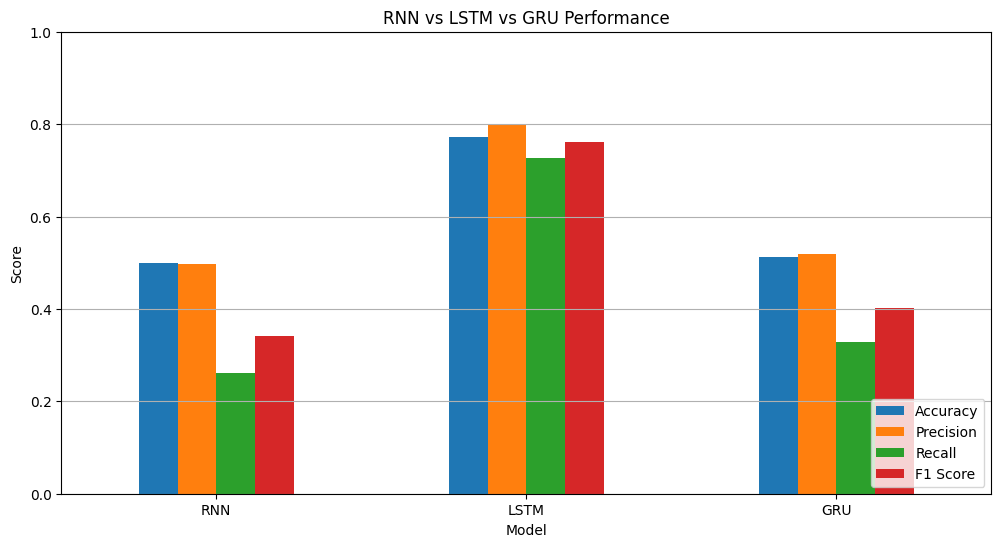

In [38]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results_df[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("RNN vs LSTM vs GRU Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")

plt.show()

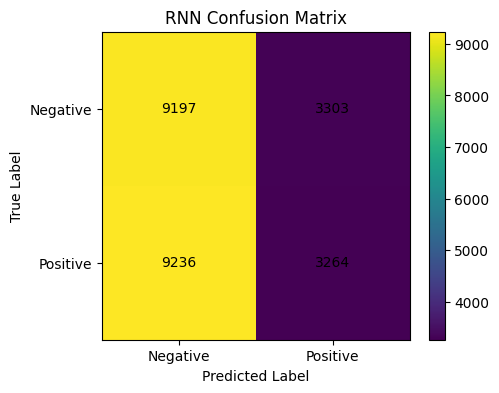

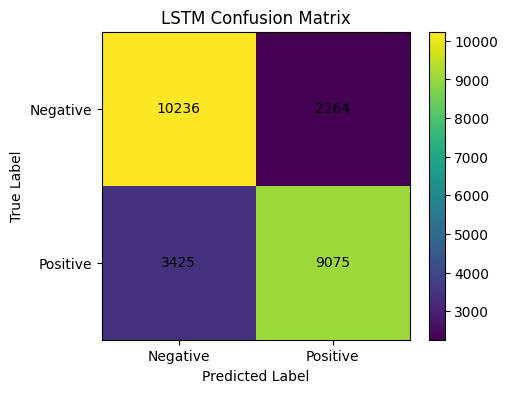

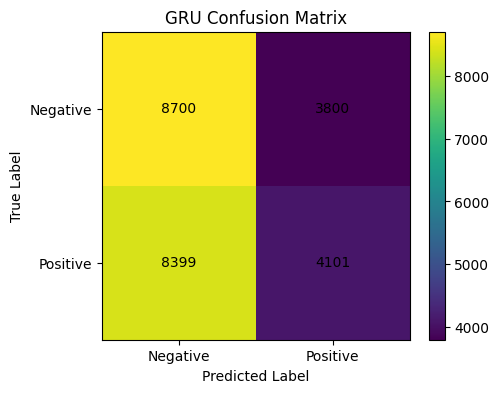

In [39]:
for name, predictions in predictions_dict.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()



In [40]:
for name, predictions in predictions_dict.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"]
        )
    )

RNN
              precision    recall  f1-score   support

    Negative       0.50      0.74      0.59     12500
    Positive       0.50      0.26      0.34     12500

    accuracy                           0.50     25000
   macro avg       0.50      0.50      0.47     25000
weighted avg       0.50      0.50      0.47     25000

LSTM
              precision    recall  f1-score   support

    Negative       0.75      0.82      0.78     12500
    Positive       0.80      0.73      0.76     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000

GRU
              precision    recall  f1-score   support

    Negative       0.51      0.70      0.59     12500
    Positive       0.52      0.33      0.40     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.49     25000
weighted avg       0.51      0.51      0.49     25000



,Model,Trainable Parameters
0,RNN,650369
1,LSTM,675137
2,GRU,667073


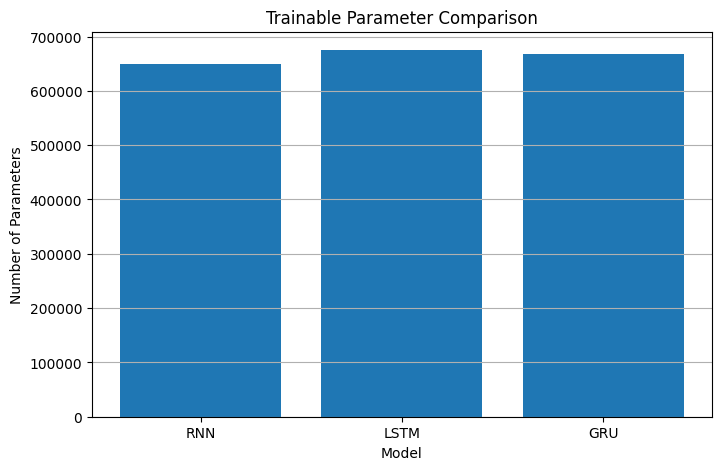

In [41]:
parameter_results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Trainable Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

display(parameter_results)

plt.figure(figsize=(8, 5))
plt.bar(
    parameter_results["Model"],
    parameter_results["Trainable Parameters"]
)
plt.title("Trainable Parameter Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.grid(axis="y")
plt.show()

In [42]:
# Training durations are not measured retrospectively by Keras.
# This cell gives the number of epochs actually completed.

training_summary = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Epochs Completed": [
        len(rnn_history.history["loss"]),
        len(lstm_history.history["loss"]),
        len(gru_history.history["loss"])
    ],
    "Final Validation Accuracy": [
        rnn_history.history["val_accuracy"][-1],
        lstm_history.history["val_accuracy"][-1],
        gru_history.history["val_accuracy"][-1]
    ],
    "Final Validation Loss": [
        rnn_history.history["val_loss"][-1],
        lstm_history.history["val_loss"][-1],
        gru_history.history["val_loss"][-1]
    ]
})

display(training_summary.round(4))


,Model,Epochs Completed,Final Validation Accuracy,Final Validation Loss
0,RNN,3,0.5048,0.7750
1,LSTM,8,0.7796,0.5134
2,GRU,2,0.6122,0.6365


In [43]:
display(results_df.round(4))

print("\nInterpretation:")
print("- RNN uses the simplest recurrent architecture.")
print("- LSTM uses memory cells and gates to handle longer dependencies.")
print("- GRU uses a simpler gated architecture and often provides a useful balance between speed and performance.")
print("- Accuracy, precision, recall, and F1 score should be considered together rather than relying on a single metric.")


,Accuracy,Precision,Recall,F1 Score
Model,,,,
RNN,0.4984,0.4970,0.2611,0.3424
LSTM,0.7724,0.8003,0.7260,0.7614
GRU,0.5120,0.5190,0.3281,0.4020



Interpretation:
- RNN uses the simplest recurrent architecture.
- LSTM uses memory cells and gates to handle longer dependencies.
- GRU uses a simpler gated architecture and often provides a useful balance between speed and performance.
- Accuracy, precision, recall, and F1 score should be considered together rather than relying on a single metric.
